<a href="https://colab.research.google.com/github/nihalodedra/placementdata_training/blob/main/placement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/modified_placement_data.csv')

In [ ]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [ ]:
df.shape

(100, 3)

In [ ]:
import matplotlib.pyplot as plt

Steps

Streamlit

0. Preprocess + EDA+ Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

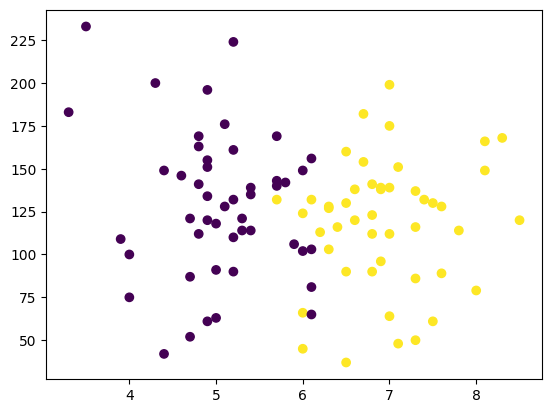

In [ ]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement_numeric'])

In [ ]:
x= df.iloc[:,0:2]
y= df.iloc[:,-1]

In [ ]:
x


,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [ ]:
y


,placement_numeric
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test =train_test_split(x,y, test_size=0.1)

In [ ]:
from sklearn.impute import SimpleImputer

# Impute missing values (NaNs) in both X_train and X_test
imputer = SimpleImputer(strategy="mean")
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)


In [ ]:
x_train


array([[  4.9       , 155.        ],
       [  5.4       , 114.        ],
       [  6.5       , 160.        ],
       [  5.1       , 128.        ],
       [  8.1       , 149.        ],
       [  4.9       , 196.        ],
       [  5.7       , 140.        ],
       [  5.        ,  91.        ],
       [  4.9       ,  61.        ],
       [  4.9       , 134.        ],
       [  3.5       , 233.        ],
       [  4.8       , 141.        ],
       [  6.1       , 156.        ],
       [  7.6       , 128.        ],
       [  3.3       , 183.        ],
       [  6.7       , 182.        ],
       [  4.6       , 146.        ],
       [  3.9       , 109.        ],
       [  5.4       , 139.        ],
       [  6.2       , 113.        ],
       [  5.2       , 132.        ],
       [  5.2       , 224.        ],
       [  5.8       , 142.        ],
       [  5.7       , 169.        ],
       [  6.8       , 123.        ],
       [  5.        ,  63.        ],
       [  6.        , 149.        ],
 

In [ ]:
y_train

,placement_numeric
76,0
41,0
38,1
86,0
37,1
...,...
54,1
29,1
71,1
59,0


In [ ]:
x_test

array([[  4.7,  87. ],
       [  6.9, 139. ],
       [  6.9, 138. ],
       [  6.5, 130. ],
       [  7.3, 116. ],
       [  4.8, 169. ],
       [  4.7,  52. ],
       [  6.1, 103. ],
       [  4.9, 120. ],
       [  6.6, 120. ]])

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)

In [ ]:
x_train

array([[-0.96411832,  0.75686336],
       [-0.52352661, -0.25283505],
       [ 0.44577514,  0.87999731],
       [-0.78788164,  0.09194002],
       [ 1.85566859,  0.60910262],
       [-0.96411832,  1.76656177],
       [-0.25917159,  0.3874615 ],
       [-0.87599998, -0.81925123],
       [-0.96411832, -1.55805495],
       [-0.96411832,  0.23970076],
       [-2.19777509,  2.67775302],
       [-1.05223666,  0.41208829],
       [ 0.09330177,  0.78149015],
       [ 1.41507689,  0.09194002],
       [-2.37401177,  1.4464135 ],
       [ 0.62201182,  1.42178671],
       [-1.22847334,  0.53522225],
       [-1.84530173, -0.375969  ],
       [-0.52352661,  0.36283471],
       [ 0.18142011, -0.27746184],
       [-0.6997633 ,  0.19044718],
       [-0.6997633 ,  2.45611191],
       [-0.17105325,  0.43671509],
       [-0.25917159,  1.10163843],
       [ 0.71013016, -0.03119393],
       [-0.87599998, -1.50880137],
       [ 0.00518343,  0.60910262],
       [ 0.71013016, -0.30208863],
       [ 0.00518343,

In [ ]:
x_test = scaler.transform(x_test)

In [ ]:
x_test

array([[-1.140355  , -0.91775839],
       [ 0.7982485 ,  0.36283471],
       [ 0.7982485 ,  0.33820792],
       [ 0.44577514,  0.1411936 ],
       [ 1.15072186, -0.20358147],
       [-1.05223666,  1.10163843],
       [-1.140355  , -1.77969606],
       [ 0.09330177, -0.52372974],
       [-0.96411832, -0.10507431],
       [ 0.53389348, -0.10507431]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
#model training
clf.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
y_test


,placement_numeric
23,0
60,1
11,1
57,1
72,1
75,0
94,0
14,0
22,0
20,1


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test, y_pred)

0.9

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

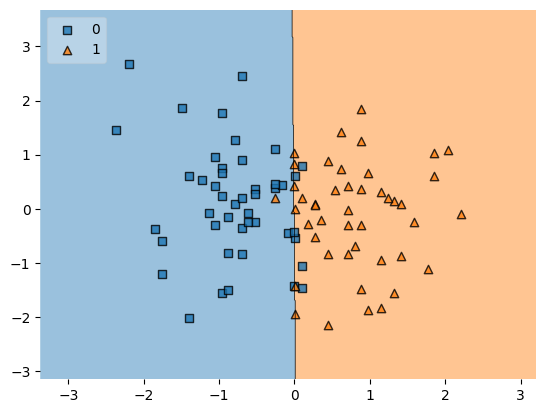

In [ ]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))